# Stage I - structural MRI measurement differences of numerical variability

## Measurements

### Data Matrix Representation

For each measurement $m$ and region of interest (ROI) $r$, we obtain data from $n$ MCA repetitions across $m$ subject/visit pairs. These observations can be represented using the design matrix $\mathcal{M}_{m,r}$:

| MCA \ Subject/Visit | $sv_1$    | $sv_2$    | $\cdots$ | $sv_{m-1}$ | $sv_m$    | Anatomical $\rightarrow$ |
|----------------------|-----------|-----------|----------|------------|-----------|--------------------------|
| $rep_1$             | $x_{1,1}$ | $x_{1,2}$ | $\cdots$ | $x_{1,m-1}$| $x_{1,m}$ | $x_{1,:}$                |
| $rep_2$             | $x_{2,1}$ | $x_{2,2}$ | $\cdots$ | $x_{2,m-1}$| $x_{2,m}$ | $x_{2,:}$                |
| $\vdots$            | $\vdots$  | $\vdots$  | $\ddots$ | $\vdots$   | $\vdots$  | $\vdots$                 |
| $rep_{n-1}$         | $x_{n-1,1}$| $x_{n-1,2}$| $\cdots$| $x_{n-1,m-1}$| $x_{n-1,m}$| $x_{n-1,:}$          |
| $rep_n$             | $x_{n,1}$ | $x_{n,2}$ | $\cdots$ | $x_{n,m-1}$| $x_{n,m}$ | $x_{n,:}$                |
| Numerical $\downarrow$ | $x_{:,1}$ | $x_{:,2}$ | $\cdots$ | $x_{:,m-1}$| $x_{:,m}$ |                          |

Data matrix of size $n \times m$ with MCA repetitions as rows ($rep_1$ to $rep_n$) and subject/visit pairs as columns ($sv_1$ to $sv_m$). Each cell $x_{i,j}$ represents the measurement for subject/visit pair $j$ during MCA repetition $i$.

### Numerical Variability


Numerical variability quantifies the extent to which measurements for a given subject vary across MCA repetitions. For each subject/visit pair $j$, this variability is computed as:

$$\text{Var}_{\text{numerical}}^{(j)} = \frac{1}{n - 1} \sum_{i=1}^n \left(x_{i,j} - \bar{x}_{:,j}\right)^2, \quad \text{with } \bar{x}_{:,j} = \frac{1}{n} \sum_{i=1}^n x_{i,j}$$


The average numerical (intra-subject) variability across all subjects is:

$$\sigma^2_{num} = \frac{1}{m} \sum_{j=1}^m \text{Var}_{\text{numerical}}^{(j)}$$

### Anatomical Variability

#### General version

Anatomical variability quantifies differences between subjects within each MCA repetition. For each repetition $i$, it is computed as:

$$\text{Var}_{\text{anatomical}}^{(i)} = \frac{1}{m - 1} \sum_{j=1}^m \left(x_{i,j} - \bar{x}_{i,:}\right)^2, \quad \text{with } \bar{x}_{i,:} = \frac{1}{m} \sum_{j=1}^m x_{i,j}$$

The average anatomical (inter-subject) variability across all repetitions is:

$$\sigma^2_{anat} = \frac{1}{n} \sum_{i=1}^n \text{Var}_{\text{anatomical}}^{(i)}$$

#### IEEE referenced

One can also use IEEE obersvation instead of MCA repetitions. Anatomical variability is computed on IEEE value 

Here $\sigma^2_{anat}$ becomes

$$\sigma^2_{anat} = \text{Var}_{\text{anatomical}}^{(\text{IEEE})}$$

### Cohens'd coefficient

Let $X_1$ and $X_2$ represent two distinct populations with $|X_1|=N$, $|X_2|=M$. Cohen's d is defined as:
$$
d = \frac{\mu_1 - \mu_2}{\sigma_{\text{pooled}}},
$$
where $\mu_1$ and $\mu_2$ are the means of populations $X_1$ and $X_2$, respectively, and $\sigma_{\text{pooled}}$ is the pooled standard deviation given by:
$$
\sigma_{\text{pooled}} = \sqrt{\frac{(N-1)\sigma^{2}_{X_1} + (M-1)\sigma^{2}_{X_2}}{N + M - 2}}.
$$

### Anatomical vs Numerical Ratio

Let $\sigma^2_{anat}$ the anatomical variability and $\sigma^2_{num}$ the numerical variability.

$$r = \frac{\sigma^2_{num}}{\sigma^2_{anat}}$$

### Anatomical vs Numerical Index

$$I = \frac{\sigma^2_{anat} - \sigma^2_{num}}{\sigma^2_{anat} + \sigma^2_{num}}$$

In [2]:
import pandas as pd
import os
import plotly.express as px
import numpy as np

root_dir = os.path.dirname(os.path.realpath("__file__"))
stats_dir = os.path.join(root_dir, "stats_QCed")

In [11]:
def compute_variability_cortical_metric(metric):
    df = pd.read_parquet(f"{stats_dir}/{metric}.parquet")
    numerical = df.groupby(["subjects","hemi"]).var().reset_index().drop(columns=["subjects"]).groupby("hemi").mean().reset_index()
    numerical = numerical.melt(
        id_vars=["hemi"], var_name="ROI", value_name="variance"
    )
    ROI_dropped = ["BrainSegVolNotVent", "eTIV"]
    numerical.drop(
        numerical[numerical["ROI"].isin(ROI_dropped)].index,
        inplace=True,
    )

    # Create column Rank with the rank of each row within the group (subjects,hemi)
    df_lh = df[df["hemi"] == "lh"].reset_index(drop=True)
    df_rh = df[df["hemi"] == "rh"].reset_index(drop=True)
    df_lh["Rank"] = (
        df_lh.sort_values(by=["subjects"])
        .rank(method="dense")["subjects"]
        .astype(int)
    )
    df_rh["Rank"] = (
        df_rh.sort_values(by=["subjects"])
        .rank(method="dense")["subjects"]
        .astype(int)
    )
    df = pd.concat([df_lh, df_rh], axis=0)
    df["Rep"] = df["Rank"]
    df["Rep"] = (
        df.groupby(["Rank", "hemi"])
        .rank(method="first")["Rep"]
        .reset_index()["Rep"]
        .astype(int)
    )

    anatomical = (
        df.drop(columns=["subjects"])
        .groupby(["Rep", "hemi"])
        .var()
        .reset_index()
        .groupby("hemi")
        .mean()
        .drop(columns=["Rep", "Rank"])
        .reset_index()
    )
    anatomical = anatomical.melt(
        id_vars=["hemi"], var_name="ROI", value_name="variance"
    )
    ROI_dropped = ["BrainSegVolNotVent", "eTIV"]
    anatomical.drop(
        anatomical[anatomical["ROI"].isin(ROI_dropped)].index,
        inplace=True,
    )
    return numerical, anatomical

## Numerical vs Anatomical Ratio

In [12]:
def compute_num_anat_ratio(numerical, anatomical):
    r_na = numerical.copy()
    r_na['r^2'] = numerical['variance'] / anatomical['variance']
    r_na['r'] = r_na['r^2'].apply(np.sqrt)
    return r_na

## Numerical vs Anatomical Index

In [13]:
def compute_num_anat_Index(numerical, anatomical):
    I_na = numerical.copy()
    I_na["I"] = (anatomical["variance"] - numerical["variance"]) / (
        numerical["variance"] + anatomical["variance"]
    )
    return I_na

In [14]:
import nibabel
from nilearn.datasets import fetch_atlas_destrieux_2009
from nilearn.plotting import view_img_on_surf, plot_img_on_surf

destrieux = fetch_atlas_destrieux_2009()

def apply_stats_on_ROI(atlas, stats_df, metric, stat, verbose=False):
    """
    Apply stats values on a reference image and return a new image
    with the same shape as the reference image.
    """
    # Load the reference image
    reference_img = nibabel.load(atlas.maps)
    reference_img_data = reference_img.get_fdata()

    hemi_dest = {'lh': 'L', 'rh': 'R'}
    # Create a label combining hemi and ROI -> L ROI and R ROI
    stats_df['ROI_destrieux'] = stats_df[['hemi','ROI']].apply(
        lambda x: f"{hemi_dest[x[0]]} {x[1].replace(f'_{metric}','')}", axis=1
    )

    # Create an empty array with the same shape as the reference image
    new_img_data = np.zeros(reference_img_data.shape)

    # Iterate through the labels and assign the corresponding stats values
    for index, row in atlas.labels.iterrows():
        label = row["name"]
        # Get the corresponding value from the stats_df
        values = stats_df.loc[stats_df["ROI_destrieux"] == label, stat].values
        value = 0 if values.size == 0 else values[0]
        if verbose:
            print(f"Index: {index}, label: {label}")
            print(f"Value: {value}")
        new_img_data[reference_img_data == index] = value

    return nibabel.Nifti1Image(new_img_data, affine=reference_img.affine, header=reference_img.header)

[get_dataset_dir] Dataset found in /home/yohan/nilearn_data/destrieux_2009


In [15]:
def plot_ROI(stat_map, title, cmap="turbo", vmin=0, vmax=.5, 
             views=["lateral"], 
             hemispheres=["left", "right"]):
    return plot_img_on_surf(
        stat_map=stat_map,
        surf_mesh="fsaverage",
        views=views,
        hemispheres=hemispheres,
        threshold=0.0000001,
        colorbar=True,        
        title=title,
        cmap=cmap,
        cbar_tick_format="%.1f",
        vmin=vmin,
        vmax=vmax)


def view_ROI(stat_map, title, cmap="turbo", vmin=0, vmax=.5, symmetric_cmap=False,
             views=["lateral"], 
             hemispheres=["left", "right"]):
    return view_img_on_surf(
        stat_map_img=stat_map,
        surf_mesh="fsaverage",
        threshold=0.0000001,
        colorbar=True,
        title=title,
        symmetric_cmap=symmetric_cmap,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        vol_to_surf_kwargs={
            "n_samples": 1,
            "radius": 0.0,
            "interpolation": "nearest",
        },
    )

### Cortical Thickness 

In [16]:
thickness_num, thickness_anat = compute_variability_cortical_metric("thickness")
thickness_r = compute_num_anat_ratio(thickness_num, thickness_anat)
thickness_stat_map_r = apply_stats_on_ROI(
    atlas=destrieux,
    stats_df=thickness_r,
    metric="thickness",
    stat="r",
)

/tmp/ipykernel_222855/3751733997.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  lambda x: f"{hemi_dest[x[0]]} {x[1].replace(f'_{metric}','')}", axis=1


[get_dataset_dir] Dataset found in /home/yohan/nilearn_data/fsaverage


(<Figure size 400x500 with 5 Axes>,
 [<Axes3D: >, <Axes3D: >, <Axes3D: >, <Axes3D: >, <Axes: >])

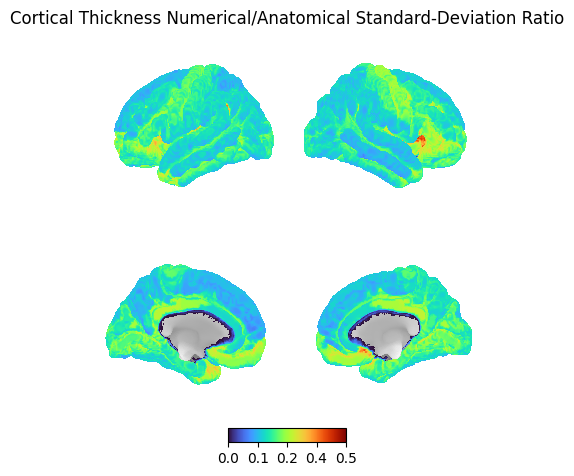

In [17]:
view = plot_ROI(
    stat_map=thickness_stat_map_r,
    title="Cortical Thickness Numerical/Anatomical Standard-Deviation Ratio",
    views=["lateral","medial"],
    hemispheres=["left", "right"],
)
view

In [18]:
view = view_ROI(
    stat_map=thickness_stat_map_r,
    title="Cortical Thickness Numerical/Anatomical Standard-Deviation Ratio",
)

view.save_as_html(
    os.path.join(
        root_dir,
        "figures",
        "thickness_num_anat_ratio.html",
    )
)

[get_dataset_dir] Dataset found in /home/yohan/nilearn_data/fsaverage


/tmp/ipykernel_184633/3751733997.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  lambda x: f"{hemi_dest[x[0]]} {x[1].replace(f'_{metric}','')}", axis=1


[get_dataset_dir] Dataset found in /home/yohan/nilearn_data/fsaverage


(<Figure size 640x480 with 3 Axes>, [<Axes3D: >, <Axes3D: >, <Axes: >])

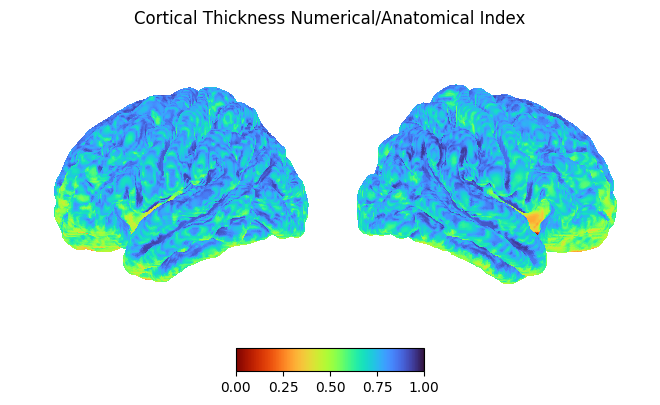

: 

: 

: 

: 

: 

: 

In [ ]:
thickness_I = compute_num_anat_Index(thickness_num, thickness_anat)
stat_map_I = apply_stats_on_ROI(
    atlas=destrieux,
    stats_df=thickness_I,
    metric="thickness",
    stat="I",
)
plot_ROI(
    stat_map=stat_map_I,
    title="Cortical Thickness Numerical/Anatomical Index",
    views=["lateral", "medial"],
    hemispheres=["left", "right"],
    cmap="turbo_r",
    vmin=0,
    vmax=1,
)

### Surface Area

In [19]:
area_num, area_anat = compute_variability_cortical_metric("area")
area_r = compute_num_anat_ratio(area_num, area_anat)
area_stat_map_r = apply_stats_on_ROI(
    atlas=destrieux,
    stats_df=area_r,
    metric="area",
    stat="r",
)

/tmp/ipykernel_222855/3751733997.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  lambda x: f"{hemi_dest[x[0]]} {x[1].replace(f'_{metric}','')}", axis=1


[get_dataset_dir] Dataset found in /home/yohan/nilearn_data/fsaverage


(<Figure size 400x500 with 5 Axes>,
 [<Axes3D: >, <Axes3D: >, <Axes3D: >, <Axes3D: >, <Axes: >])

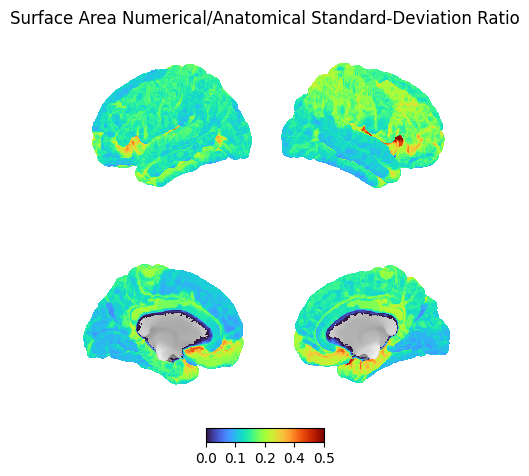

In [23]:
view = plot_ROI(
    stat_map=area_stat_map_r,
    title="Surface Area Numerical/Anatomical Standard-Deviation Ratio",
    views=["lateral", "medial"],
    hemispheres=["left", "right"],
)
display(view)

In [20]:
view = view_ROI(
    stat_map=area_stat_map_r,
    title="Surface Area Numerical/Anatomical Standard-Deviation Ratio",
)

view.save_as_html(
    os.path.join(
        root_dir,
        "figures",
        "area_num_anat_ratio.html",
    )
)

[get_dataset_dir] Dataset found in /home/yohan/nilearn_data/fsaverage


/tmp/ipykernel_184633/3751733997.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  lambda x: f"{hemi_dest[x[0]]} {x[1].replace(f'_{metric}','')}", axis=1


[get_dataset_dir] Dataset found in /home/yohan/nilearn_data/fsaverage


(<Figure size 640x480 with 3 Axes>, [<Axes3D: >, <Axes3D: >, <Axes: >])

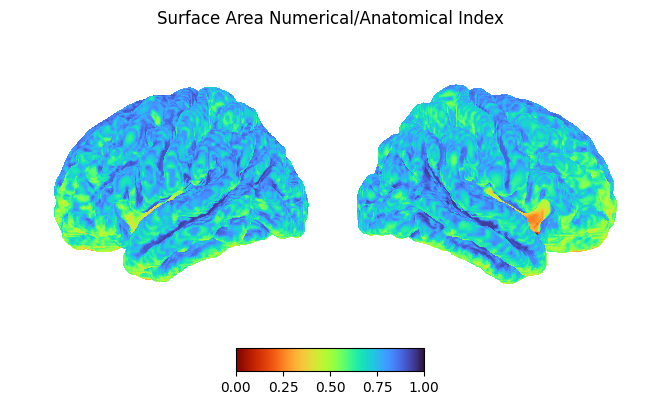

: 

: 

: 

: 

: 

: 

In [ ]:
area_I = compute_num_anat_Index(area_num, area_anat)
stat_map_I = apply_stats_on_ROI(
    atlas=destrieux,
    stats_df=area_I,
    metric="area",
    stat="I",
)
plot_ROI(
    stat_map=stat_map_I,
    title="Surface Area Numerical/Anatomical Index",
    views=["lateral", "medial"],
    hemispheres=["left", "right"],
    cmap="turbo_r",
    vmin=0,
    vmax=1,
)

### Cortical Volume

In [21]:
volume_num, volume_anat = compute_variability_cortical_metric("volume")
volume_r = compute_num_anat_ratio(volume_num, volume_anat)
volume_stat_map_r = apply_stats_on_ROI(
    atlas=destrieux,
    stats_df=volume_r,
    metric="volume",
    stat="r",
)

/tmp/ipykernel_222855/3751733997.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  lambda x: f"{hemi_dest[x[0]]} {x[1].replace(f'_{metric}','')}", axis=1


[get_dataset_dir] Dataset found in /home/yohan/nilearn_data/fsaverage


(<Figure size 400x500 with 5 Axes>,
 [<Axes3D: >, <Axes3D: >, <Axes3D: >, <Axes3D: >, <Axes: >])

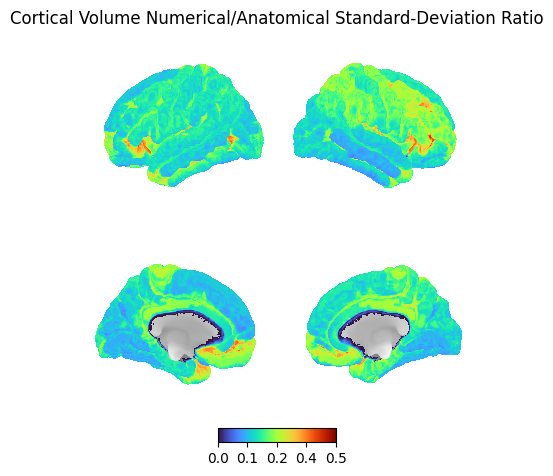

In [24]:
view = plot_ROI(
    stat_map=volume_stat_map_r,
    title="Cortical Volume Numerical/Anatomical Standard-Deviation Ratio",
    views=["lateral", "medial"],
    hemispheres=["left", "right"],
)
display(view)

In [22]:
view = view_ROI(
    stat_map=volume_stat_map_r,
    title="Cortical Volume Numerical/Anatomical Standard-Deviation Ratio",
)

view.save_as_html(
    os.path.join(
        root_dir,
        "figures",
        "volume_num_anat_ratio.html",
    )
)

[get_dataset_dir] Dataset found in /home/yohan/nilearn_data/fsaverage


/tmp/ipykernel_184633/3751733997.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  lambda x: f"{hemi_dest[x[0]]} {x[1].replace(f'_{metric}','')}", axis=1


[get_dataset_dir] Dataset found in /home/yohan/nilearn_data/fsaverage


(<Figure size 640x480 with 3 Axes>, [<Axes3D: >, <Axes3D: >, <Axes: >])

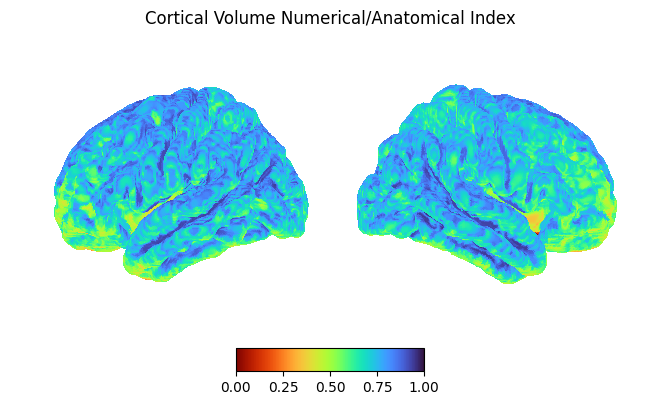

: 

: 

: 

: 

: 

: 

In [ ]:
volume_I = compute_num_anat_Index(volume_num, volume_anat)
stat_map_I = apply_stats_on_ROI(
    atlas=destrieux,
    stats_df=volume_I,
    metric="volume",
    stat="I",
)
plot_ROI(
    stat_map=stat_map_I,
    title="Cortical Volume Numerical/Anatomical Index",
    views=["lateral", "medial"],
    hemispheres=["left", "right"],
    cmap="turbo_r",
    vmin=0,
    vmax=1,
)

In [4]:
import dis
from enigmatoolbox.plotting import plot_subcortical


# def compute_variability_subcortical_volume():
df = pd.read_parquet(f"{stats_dir}/subcortical_volume.parquet")
numerical = (
    df.groupby(["subjects"])
    .var()
    .reset_index()
    .drop(columns=["subjects"])
    .mean()
    .reset_index()
)
numerical = numerical.melt(var_name="ROI", value_name="variance")
ROI_dropped = ["BrainSegVolNotVent", "eTIV"]
numerical.drop(
    numerical[numerical["ROI"].isin(ROI_dropped)].index,
    inplace=True,
)
display(numerical)
# Create column Rank with the rank of each row within the group (subjects,hemi)
df["Rank"] = (
    df.sort_values(by=["subjects"]).rank(method="dense")["subjects"].astype(int)
)
df["Rep"] = df["Rank"]
df["Rep"] = (
    df.groupby(["Rank"])
    .rank(method="first")["Rep"]
    .reset_index()["Rep"]
    .astype(int)
)

anatomical = (
    df.drop(columns=["subjects"])
    .groupby(["Rep"])
    .var()
    .reset_index()
    .mean()
    .drop(columns=["Rep", "Rank"])
    .reset_index()
)
anatomical = anatomical.melt(
    var_name="ROI", value_name="variance"
)
ROI_dropped = ["BrainSegVolNotVent", "eTIV"]
anatomical.drop(
    anatomical[anatomical["ROI"].isin(ROI_dropped)].index,
    inplace=True,
)

#   return numerical, anatomical

,ROI,variance
0,index,Left-Lateral-Ventricle
1,index,Left-Inf-Lat-Vent
2,index,Left-Cerebellum-White-Matter
3,index,Left-Cerebellum-Cortex
4,index,Left-Thalamus
...,...,...
123,0,0.000003
124,0,68.027111
125,0,44.040832
126,0,124.251335


ValueError: cannot reindex on an axis with duplicate labels